# Instalar librerías

In [1]:
!pip install rasterio folium geopandas branca -q

# Descargar el sample.tif

In [2]:
!wget -O sample.tif https://github.com/mommermi/geotiff_sample/raw/master/sample.tif

--2026-06-02 01:22:05--  https://github.com/mommermi/geotiff_sample/raw/master/sample.tif
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mommermi/geotiff_sample/master/sample.tif [following]
--2026-06-02 01:22:06--  https://raw.githubusercontent.com/mommermi/geotiff_sample/master/sample.tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6018396 (5.7M) [image/tiff]
Saving to: ‘sample.tif’

sample.tif          100%[===================>]   5.74M  --.-KB/s    in 0.08s   

2026-06-02 01:22:06 (68.0 MB/s) - ‘sample.tif’ saved [6018396/6018396]



# Leer el GeoTIFF y mostrar información

In [3]:
import rasterio

src = rasterio.open("sample.tif")

print("Metadatos:")
print(src.meta)

print("\nBounds:")
print(src.bounds)

print("\nCRS:")
print(src.crs)

Metadatos:
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 1001, 'height': 1001, 'count': 3, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]'), 'transform': Affine(10.0, 0.0, 590520.0,
       0.0, -10.0, 5790630.0)}

Bounds:
BoundingBox(left=590520.0, bottom=5780620.0, right=600530.0, top=5790630.0)

CRS:
EPSG:32631


# Visualizar la imagen satelital

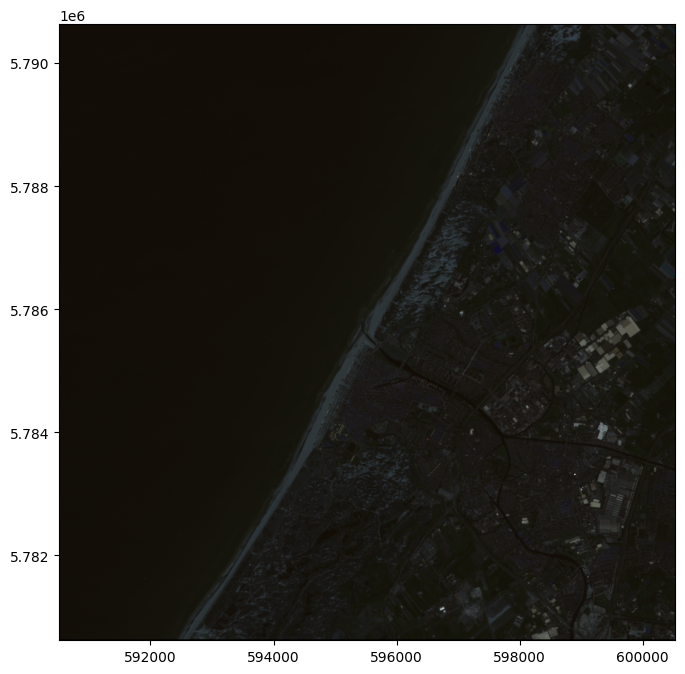

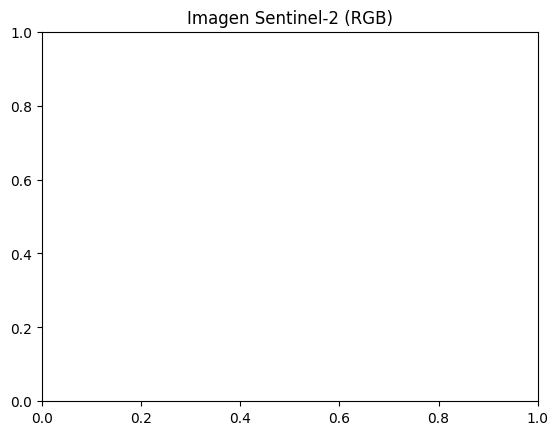

In [4]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

src = rasterio.open("sample.tif")

plt.figure(figsize=(8,8))
show(src)
plt.title("Imagen Sentinel-2 (RGB)")
plt.show()

# Visualización RGB

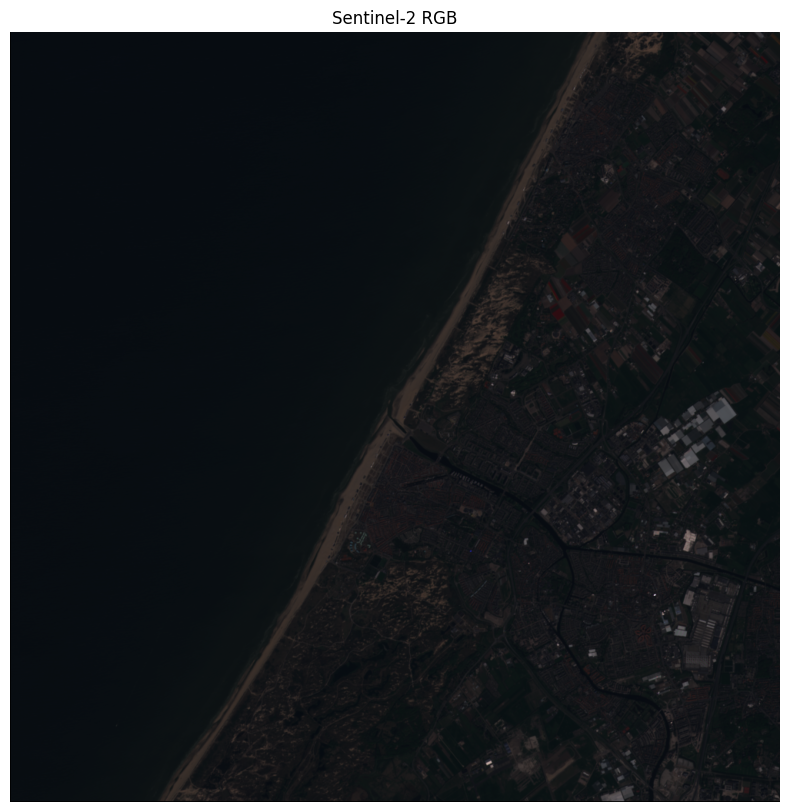

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open("sample.tif") as src:
    img = src.read()

rgb = np.dstack([
    img[2],
    img[1],
    img[0]
])

rgb = rgb.astype(float)
rgb = rgb / rgb.max()

plt.figure(figsize=(10,10))
plt.imshow(rgb)
plt.axis("off")
plt.title("Sentinel-2 RGB")
plt.show()

# Crear mapa interactivo con Folium

In [6]:
import folium

m = folium.Map(
    location=[4.7110, -74.0721],
    zoom_start=10
)

folium.TileLayer("OpenStreetMap").add_to(m)
folium.TileLayer("CartoDB positron").add_to(m)
folium.TileLayer("CartoDB dark_matter").add_to(m)

folium.LayerControl().add_to(m)

m

# Agregar un marcador interactivo

In [7]:
import folium

m = folium.Map(
    location=[4.7110, -74.0721],
    zoom_start=10
)

folium.Marker(
    [4.7110, -74.0721],
    popup="Bogotá",
    tooltip="Haz clic"
).add_to(m)

folium.LayerControl().add_to(m)

m

# Mostrar coordenadas al hacer clic

In [8]:
import folium

m = folium.Map(
    location=[4.7110, -74.0721],
    zoom_start=10
)

m.add_child(folium.LatLngPopup())

m

# Exportar el mapa HTML

In [9]:
m.save("mapa_interactivo.html")

print("Mapa exportado")

Mapa exportado


# Bonus

In [11]:
!wget -O colombia.geojson https://raw.githubusercontent.com/johan/world.geo.json/master/countries/COL.geo.json

--2026-06-02 01:25:37--  https://raw.githubusercontent.com/johan/world.geo.json/master/countries/COL.geo.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2368 (2.3K) [text/plain]
Saving to: ‘colombia.geojson’

colombia.geojson    100%[===================>]   2.31K  --.-KB/s    in 0s      

2026-06-02 01:25:37 (21.1 MB/s) - ‘colombia.geojson’ saved [2368/2368]



    id      name                                           geometry
0  COL  Colombia  POLYGON ((-75.37322 -0.15203, -75.80147 0.0848...


<Axes: >

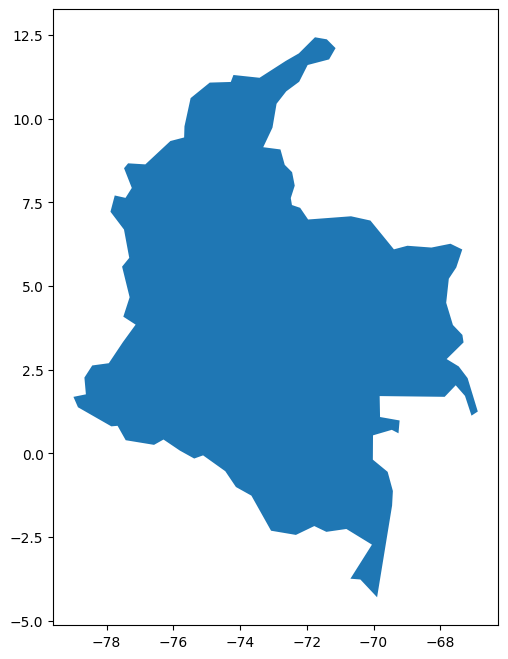

In [13]:
import geopandas as gpd

gdf = gpd.read_file("colombia.geojson")

print(gdf.head())
gdf.plot(figsize=(8,8))

# Integrarlo con Folium

In [14]:
import geopandas as gpd
import folium

gdf = gpd.read_file("colombia.geojson")

m = folium.Map(
    location=[4.57, -74.29],
    zoom_start=5
)

folium.GeoJson(
    gdf,
    name="Colombia"
).add_to(m)

folium.LayerControl().add_to(m)

m

In [15]:
import geopandas as gpd
from shapely.geometry import Polygon

poly = Polygon([
    (-74.2, 4.5),
    (-74.0, 4.5),
    (-74.0, 4.8),
    (-74.2, 4.8)
])

gdf = gpd.GeoDataFrame(
    {"nombre": ["Zona de ejemplo"]},
    geometry=[poly],
    crs="EPSG:4326"
)

gdf

,nombre,geometry
0,Zona de ejemplo,"POLYGON ((-74.2 4.5, -74 4.5, -74 4.8, -74.2 4..."


In [16]:
import folium

m = folium.Map(
    location=[4.65, -74.1],
    zoom_start=11
)

folium.GeoJson(
    gdf,
    tooltip="Zona de ejemplo"
).add_to(m)

folium.LayerControl().add_to(m)

m